# SIR Homework 1 Problem 1
We'll first plot the normal SIR model just tweaking the initial condintions. I also added a print of the final state of the recovered. 

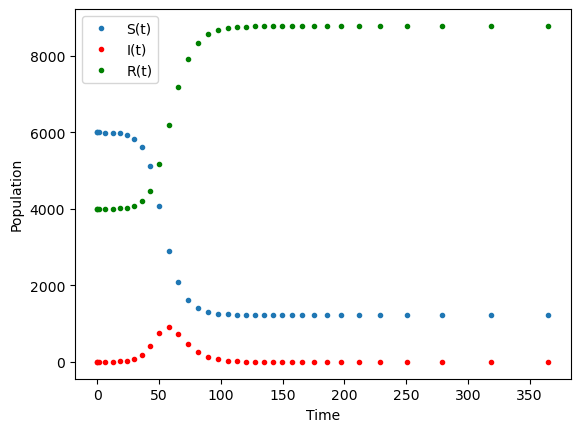

8781.25358504853


In [6]:
import numpy as np
import matplotlib.pyplot as plt #Matplotlib is used to generate our plots
from scipy.integrate import solve_ivp #We will use solve_ivp to numerically solve the system of differential equations. 

# Define the system of ODEs
def sirsys1(t, y): #y is a vector whose components are Susceptibles, Infected, Recovered respectively
    S, I, R = y
    dS_dt = -a * S * I
    dI_dt = a * S * I - b * I
    dR_dt = b * I
    return [dS_dt, dI_dt, dR_dt]

# Time range and initial conditions
a = 0.00005
b = 0.15
t_span = (0, 365)
y0=[5999,1,4000] #Initial conditions for Susceptible, Infectious, Recovered stored as a vector y0. 

# Specify error tolerences, that is how accurately our Initial Value Problem will be solved numerically 
rtol = 1e-4
atol = 1e-4

# Solve the system
sol = solve_ivp(sirsys1, t_span, y0, method='RK45', rtol=rtol, atol=atol)
#Note that "Runge-Kutta 45" is a standard numerical method to solve IVPs with specified absolute and relative error tolerances.

# Plotting the results
plt.plot(sol.t, sol.y[0], '.', label='S(t)')
plt.plot(sol.t, sol.y[1], '.', color='r', label='I(t)')
plt.plot(sol.t, sol.y[2], '.', color='g', label='R(t)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()
print(sol.y[2][-1])


Let's contrast that with implementing Town B

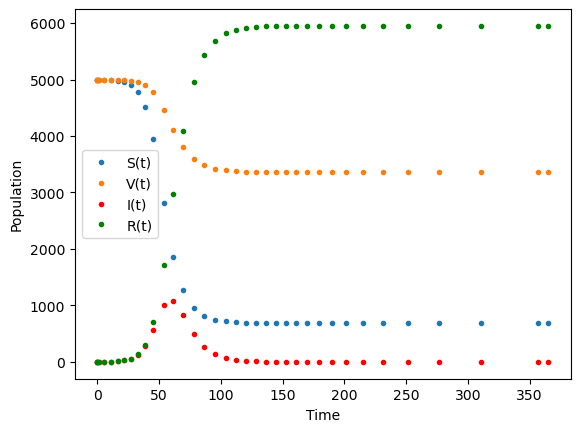

5948.789708319082


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Define the system of ODEs for Town B
def sirsys1(t, y):
    S, V, I, R = y
    dS_dt = -a * S * I
    dV_dt = -(a/5) * V * I
    dI_dt = a * S * I + (a/5) * V * I - b * I
    dR_dt = b * I
    return [dS_dt, dV_dt, dI_dt, dR_dt]

# Time range and initial conditions
a = 0.00005
b = 0.15
t_span = (0, 365)
y0 = [4999, 5000, 1, 0]   # S, V, I, R

# Specify error tolerances
rtol = 1e-4
atol = 1e-4

# Solve the system
sol = solve_ivp(sirsys1, t_span, y0, method='RK45',
                rtol=rtol, atol=atol)

# Plotting the results
plt.plot(sol.t, sol.y[0], '.', label='S(t)')
plt.plot(sol.t, sol.y[1], '.', label='V(t)')
plt.plot(sol.t, sol.y[2], '.', color='r', label='I(t)')
plt.plot(sol.t, sol.y[3], '.', color='g', label='R(t)')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()

print(sol.y[3][-1])